In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [3]:
print(df.shape)

(1436, 11)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
None


In [5]:
print(df.isnull().sum())

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64


In [6]:
print(df.describe)

<bound method NDFrame.describe of       Price  Age_08_04     KM Fuel_Type   HP  Automatic    cc  Doors  \
0     13500         23  46986    Diesel   90          0  2000      3   
1     13750         23  72937    Diesel   90          0  2000      3   
2     13950         24  41711    Diesel   90          0  2000      3   
3     14950         26  48000    Diesel   90          0  2000      3   
4     13750         30  38500    Diesel   90          0  2000      3   
...     ...        ...    ...       ...  ...        ...   ...    ...   
1431   7500         69  20544    Petrol   86          0  1300      3   
1432  10845         72  19000    Petrol   86          0  1300      3   
1433   8500         71  17016    Petrol   86          0  1300      3   
1434   7250         70  16916    Petrol   86          0  1300      3   
1435   6950         76      1    Petrol  110          0  1600      5   

      Cylinders  Gears  Weight  
0             4      5    1165  
1             4      5    1165  
2 

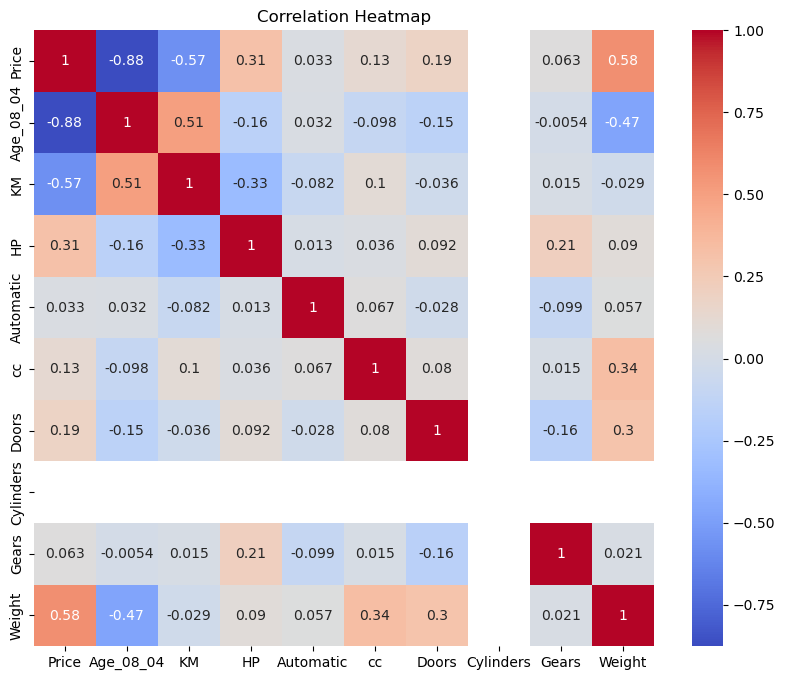

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

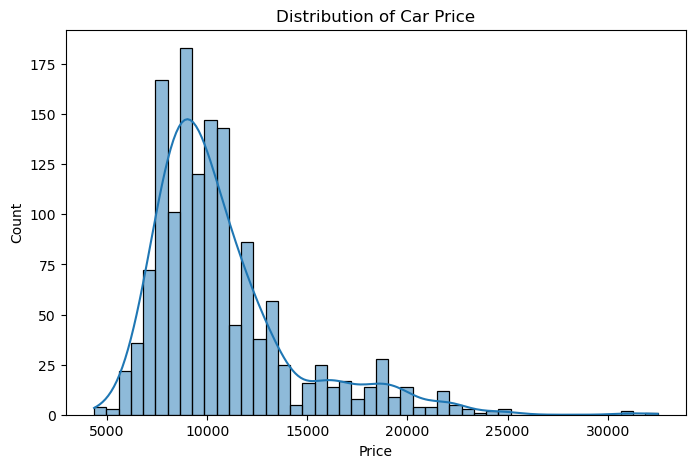

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of Car Price')
plt.show()

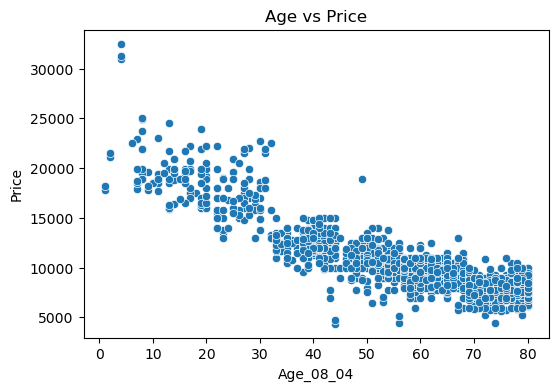

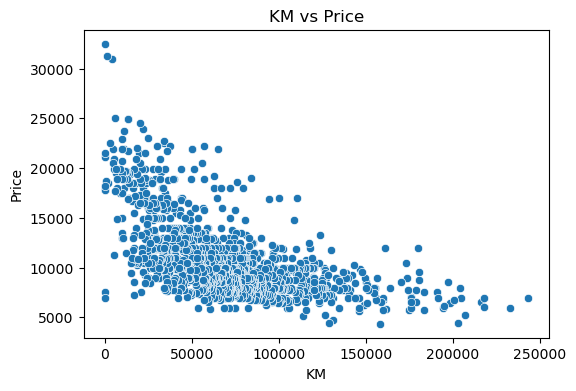

In [9]:
# Age vs Price
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Age_08_04'], y=df['Price'])
plt.title('Age vs Price')
plt.show()

# KM vs Price
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['KM'], y=df['Price'])
plt.title('KM vs Price')
plt.show()

In [10]:
X = df.drop('Price', axis=1)
y = df['Price']

In [11]:
X

,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,23,46986,Diesel,90,0,2000,3,4,5,1165
1,23,72937,Diesel,90,0,2000,3,4,5,1165
2,24,41711,Diesel,90,0,2000,3,4,5,1165
3,26,48000,Diesel,90,0,2000,3,4,5,1165
4,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...
1431,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,70,16916,Petrol,86,0,1300,3,4,5,1015


In [12]:
y

0       13500
1       13750
2       13950
3       14950
4       13750
        ...  
1431     7500
1432    10845
1433     8500
1434     7250
1435     6950
Name: Price, Length: 1436, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [15]:
categorical_cols = ['Fuel_Type']

numerical_cols = [col for col in X.columns if col not in categorical_cols]

In [16]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1148, 10)
Testing Data Shape: (288, 10)


In [18]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

In [20]:
lasso_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.1))
])

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

In [21]:
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

In [22]:
# Function for evaluation

def evaluate_model(y_test, y_pred, model_name):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

# Evaluating all models

evaluate_model(y_test, lr_pred, "Linear Regression")
evaluate_model(y_test, lasso_pred, "Lasso Regression")
evaluate_model(y_test, ridge_pred, "Ridge Regression")


Linear Regression
MAE: 990.8872739193971
RMSE: 1484.2654153296521
R2 Score: 0.834888804061108

Lasso Regression
MAE: 990.9037441274195
RMSE: 1483.929041092914
R2 Score: 0.8349636328061677

Ridge Regression
MAE: 990.7316194685651
RMSE: 1482.3945976509578
R2 Score: 0.8353047650767529


In [23]:
#Interpretation of Model Coefficients

feature_names = numerical_cols + list(
    lr_model.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
)

coefficients = lr_model.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

print(coef_df.sort_values(by='Coefficient', ascending=False))

             Feature   Coefficient
10  Fuel_Type_Petrol  1.370809e+03
8             Weight  1.316818e+03
2                 HP  2.083499e+02
7              Gears  1.093404e+02
3          Automatic  3.439713e+01
6          Cylinders -5.684342e-14
4                 cc -1.416192e+01
5              Doors -5.746780e+01
9   Fuel_Type_Diesel -6.854876e+01
1                 KM -6.116544e+02
0          Age_08_04 -2.267295e+03


In [24]:
# Identify the Weakest Feature
coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])

weakest_feature = coef_df.sort_values(
    by='Abs_Coefficient'
).iloc[0]

print(weakest_feature)

Feature            Cylinders
Coefficient             -0.0
Abs_Coefficient          0.0
Name: 6, dtype: object


In [25]:
X = df.drop('Price', axis=1)

In [26]:
X_weak = df[["Age_08_04"]]

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_weak, y, test_size=0.2, random_state=42
)

model_weak = LinearRegression()

model_weak.fit(X_train_w, y_train_w)

pred_weak = model_weak.predict(X_test_w)

print("R2:", r2_score(y_test_w, pred_weak))

R2: 0.7569201277242213


In [27]:
X_new = X.drop(columns=["Age_08_04"])

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)



In [28]:
numerical_cols_new = X_new.select_dtypes(include=['int64','float64']).columns
categorical_cols_new = X_new.select_dtypes(include=['object']).columns

# Preprocessing
preprocessor_new = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols_new),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_new)
    ]
)

# Pipeline
model_new = Pipeline([
    ('preprocessor', preprocessor_new),
    ('model', LinearRegression())
])

# Train model
model_new.fit(X_train_n, y_train_n)

# Predictions
pred_new = model_new.predict(X_test_n)

# Evaluation
mae_new = mean_absolute_error(y_test_n, pred_new)
rmse_new = np.sqrt(mean_squared_error(y_test_n, pred_new))
r2_new = r2_score(y_test_n, pred_new)

print("Model After Removing Weakest Feature")
print("MAE :", mae_new)
print("RMSE:", rmse_new)
print("R² Score:", r2_new)

Model After Removing Weakest Feature
MAE : 1553.0989886794162
RMSE: 2406.4577186639804
R² Score: 0.5659798847486817


In [30]:
#Q1. What is Multiple Linear Regression?

#Answer: A statistical technique used to predict a dependent variable using multiple independent variables.

#Q2. Difference between Simple and Multiple Linear Regression?

#Answer: Simple uses one predictor, Multiple uses more than one predictor.

#Q3. What is Multicollinearity?

#Answer: High correlation among independent variables.

#Q4. What is R² Score?

#Answer: Percentage of variance explained by the model.

#Q5. What is MAE?

#Answer: Average absolute prediction error.

#Q6. What is RMSE?

#Answer: Square root of mean squared error.

#Q7. What is Ridge Regression?

#Answer: Regression with L2 regularization.

#Q8. What is Lasso Regression?

#Answer: Regression with L1 regularization that can perform feature selection.

#Q9. Why is feature scaling important?

#Answer: It ensures features contribute equally to model training.

#Q10. How do you identify the weakest feature?

#Answer: By finding the feature with the smallest absolute coefficient.